# Introduction:

Before we delve further into the mathematical part, it's crucial to understand **why** we are exploring data types. In Data Mining and Machine Learning, the algorithms we use are fundamentally mathematical. They expect to be fed specific structures of data to work correctly.

However, real-world data is messy. It's not just numbers; it's text, categories, rankings, and binary values (True/False). 

### The "Why" and "What's the Use":
1. **Choosing the Right Algorithm**: Some algorithms only work well with continuous numbers (like Linear Regression or K-Means Clustering). Others work naturally with categories (like Decision Trees or Naive Bayes). If you don't know your data type, you can't choose the right model.
   
2. **Data Transformation & Encoding**: Because many algorithms only understand numbers, we must convert text categories (like 'Red', 'Blue', 'Green') into a numeric format. *How* we do this depends entirely on whether the data is *Nominal* (no inherent order) or *Ordinal* (has a logical order).
   
3. **Avoiding Fatal Analytical Errors**: If we accidentally treat a "Zip Code" or "ID Number" (which are nominal categories disguised as numbers) as a numeric scale, an algorithm might think that Zip Code 90210 is "greater than" Zip Code 10001. This will completely ruin your analysis and predictions.
   
4. **Correct Statistical Measurement**: As we will see in this notebook, calculating the "average" (mean) of a nominal category like 'Hair Color' is mathematically invalid and meaningless. Knowing your data type dictates which statistical measures (Mean, Median, Mode) are actually safe and valid to use.

With familirazation in these data types, we are learning the **grammar** of Data Mining. It tells  what operations you *can* and *cannot* mathematically perform on your data.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Types of Data Attributes

It's important to understand the different types of data (attributes) we encounter in Data Mining. We generally classify data into the following levels of measurement:

### 1. Categorical (Qualitative) Data

* **Nominal**: These are basic categories with **no specific order**. You can't say one is "greater" or "less" than another. 
  * *Examples:* Hair Color (Black, Blonde, Brown), Blood Type (A, B, O).
  
* **Binary**: A special type of nominal data that only has **two possible values**.
  * *Symmetric Binary*: Both outcomes are equally important (e.g., Gender: Male/Female).
  * *Asymmetric Binary*: One outcome is the main focus or "positive" event, usually rarer (e.g., HIV test result: Positive/Negative).
  
* **Ordinal**: These are categories that have a **meaningful order or ranking**, but the exact difference between the ranks is unknown.
  * *Examples:* Education Level (High School < Bachelor < Master < PhD), Customer Satisfaction (1 to 5 stars).

### 2. Numeric (Quantitative) Data

* **Interval**: Numbers where the **difference** between two values is meaningful, but there is **no true zero point**. A value of 0 doesn't mean "nothing". 
  * *Example:* Temperature in Celsius. 0°C does not mean "no temperature", and 20°C is not "twice as hot" as 10°C.
  
* **Ratio**: Numbers that have a **true zero point**. This means a value of 0 actually means "nothing" or "none", and we can calculate meaningful ratios.
  * *Examples:* Age, Salary, Height. Someone earning $100,000 makes exactly twice as much as someone earning $50,000.

### Understanding the NumPy Functions Used Below

To build our sample dataset, we use a few powerful tools from the `numpy` library (imported as `np`) to generate random but realistic data:

* **`np.random.choice(choices, size, p)`**: Picks a random item from a list of `choices`. The `size` tells it how many items to generate (e.g., $n=200$). The `p` parameter allows us to set probabilities so some choices appear more often than others (e.g., setting "O" blood type to be more common).
  
* **`np.random.randint(low, high, size)`**: Generates random whole numbers (integers) between `low` and `high`. Perfect for things like `age`.
  
* **`np.random.normal(mean, std_dev, size)`**: Generates numbers following a "Normal" (Bell Curve) distribution. Most values will be close to the `mean` (average), and `std_dev` controls how spread out they are. We use this for `height_cm` and `temp_celsius`.
  
* **`np.random.lognormal(...)`**: Generates a distribution that is "skewed" with a long tail on the right. This is excellent for modeling real-world variables like `salary_usd`, where most people earn a typical amount, but a few people earn significantly more.

In [15]:
# ── Construct a rich dataset covering all attribute types ──────────────
np.random.seed(42)
n = 200

data = pd.DataFrame({
    # Nominal
    'hair_color':      np.random.choice(['Black','Brown','Blonde','Red'], n, p=[0.4,0.35,0.15,0.1]),
    'blood_type':      np.random.choice(['A','B','AB','O'], n, p=[0.3,0.2,0.1,0.4]),
    # Binary (symmetric)
    'gender':          np.random.choice(['Male','Female'], n),
    # Binary (asymmetric) — 1 = positive (the "important" outcome)
    'hiv_positive':    np.random.choice([0, 1], n, p=[0.97, 0.03]),
    # Ordinal
    'education':       np.random.choice(
                           ['High School','Bachelor','Master','PhD'],
                           n, p=[0.3,0.4,0.2,0.1]),
    'satisfaction':    np.random.choice([1,2,3,4,5], n),
    # Interval (no true zero — °C temperature)
    'temp_celsius':    np.random.normal(20, 8, n).round(1),
    # Ratio (true zero)
    'age':             np.random.randint(18, 70, n).astype(float),
    'salary_usd':      np.random.lognormal(mean=np.log(50000), sigma=0.5, size=n).round(2),
    'height_cm':       np.random.normal(170, 10, n).round(1),
})

print("Dataset shape:", data.shape)
print(" First 5 rows:")
data.head(20)

Dataset shape: (200, 10)
 First 5 rows:


,hair_color,blood_type,gender,hiv_positive,education,satisfaction,temp_celsius,age,salary_usd,height_cm
0,Black,O,Male,0,Bachelor,5,20.7,62.0,54811.97,179.5
1,Red,A,Female,0,High School,3,28.5,68.0,54348.00,136.1
2,Brown,A,Male,0,Bachelor,5,15.9,36.0,40894.91,168.9
3,Brown,O,Male,0,High School,3,31.3,63.0,57485.81,169.3
4,Black,O,Female,0,High School,4,38.4,53.0,68104.10,165.9
5,Black,A,Female,0,PhD,5,17.1,62.0,53653.21,173.0
6,Black,A,Female,0,Bachelor,4,16.4,25.0,64392.23,176.6
7,Blonde,O,Male,0,Master,2,31.6,46.0,82039.41,171.4
8,Brown,A,Female,0,High School,2,32.6,49.0,19817.25,166.3
9,Brown,A,Male,0,Bachelor,1,15.8,68.0,80138.38,176.3


### Understanding the Data Description Table

In the next step, we create a summary table that describes each column (attribute) in our dataset. Here is what each part means in simple language:

* **Attribute**: The name of the column (e.g., `hair_color`, `age`).
  
* **Dtype**: The programming data type Pandas uses to store this information (e.g., `object` for text, `float64` for decimals).
  
* **Type_Level**: The conceptual "level of measurement" for the data. Is it a category (`Nominal`), an order (`Ordinal`), or a continuous number (`Interval`/`Ratio`)?
  
* **Unique_Values**: How many different, distinct values exist in that column.
  
* **Mode**: The most frequent value that appears in that column.
  
* **Mean_Valid**: Can we calculate an average (mean) for this data? A green checkmark (✅) means yes (for numbers like age or salary), and a red cross (❌) means no (you can't calculate the average of "hair color").
  
* **Ratio_Valid**: Can we calculate meaningful ratios for this data? (e.g., "Person A is *twice* as tall as Person B"). ✅ for `Ratio` data, ❌ for everything else.

In [16]:
# ── Describe each attribute's type and valid statistics ────────────────
# 1. Get the names of the columns
column_names = data.columns

# 2. Find out the programming data type (like text or numbers) for each column
data_types = [str(data[c].dtype) for c in data.columns]

# 3. Manually define the statistical data type for each of our 10 columns
type_levels = [
    'Nominal', 'Nominal', 'Binary-Sym', 'Binary-Asym', 
    'Ordinal', 'Ordinal', 'Interval', 'Ratio', 'Ratio', 'Ratio'
]

# 4. Count how many unique values are in each column
unique_counts = [data[c].nunique() for c in data.columns]

# 5. Find the most common value (mode) in each column
modes = [data[c].mode()[0] for c in data.columns]

# 6. Can we calculate the average (mean) for these?
mean_is_valid = ['❌', '❌', '❌', '❌', '❌', '❌', '✅', '✅', '✅', '✅']

# 7. Can we calculate ratios (e.g., "twice as much")?
ratio_is_valid = ['❌', '❌', '❌', '❌', '❌', '❌', '❌', '✅', '✅', '✅']

# Combine all these lists into one DataFrame (table) to view them together
type_summary = pd.DataFrame({
    'Attribute': column_names,
    'Dtype': data_types,
    'Type_Level': type_levels,
    'Unique_Values': unique_counts,
    'Mode': modes,
    'Mean_Valid': mean_is_valid,
    'Ratio_Valid': ratio_is_valid
})

type_summary

,Attribute,Dtype,Type_Level,Unique_Values,Mode,Mean_Valid,Ratio_Valid
0,hair_color,object,Nominal,4,Black,❌,❌
1,blood_type,object,Nominal,4,O,❌,❌
2,gender,object,Binary-Sym,2,Male,❌,❌
3,hiv_positive,int64,Binary-Asym,2,0,❌,❌
4,education,object,Ordinal,4,Bachelor,❌,❌
5,satisfaction,int64,Ordinal,5,2,❌,❌
6,temp_celsius,float64,Interval,139,21.6,✅,❌
7,age,float64,Ratio,50,37.0,✅,✅
8,salary_usd,float64,Ratio,200,14552.34,✅,✅
9,height_cm,float64,Ratio,153,161.4,✅,✅


In [17]:
BLUE   = '#38BDF8'
AMBER  = '#FBBF24'
GREEN  = '#4ADE80'
RED    = '#F87171'
PURPLE = '#A78BFA'
MUTED  = '#94A3B8'

### Visualization Part

Next, we will plot our data to see the shape of different data types. We use the `matplotlib.pyplot` library (imported as `plt`). Here is how we build the charts:

* **`plt.subplots(2, 4)`**: This creates a grid of empty charts: 2 rows and 4 columns. It returns the `fig` (the whole canvas) and `axes` (the individual charts).
  
* **Bar Charts (`ax.bar`)**: We use bar charts for *Categorical Data* (Nominal, Binary, Ordinal). A bar chart counts how many times each distinct category appears and plots a bar for that count. 
  * Notice how for **Ordinal** data (`education`), we use `.reindex()` to manually set the order of the bars from "High School" to "PhD" so the chart respects the logical ranking!
  
* **Histograms (`ax.hist`)**: We use histograms for *Numeric Data* (Interval, Ratio). Since numeric data is continuous (e.g., $171.4$ cm), we cannot plot every single distinct number. A histogram groups these numbers into ranges or "bins" (like 20-30, 30-40) and counts how many values fall into each bin.
  
* **`ax.axvline(0, ...)`**: This simply draws a vertical line at $x=0$. We do this on the temperature chart to show that $0$ is just an arbitrary point on the scale (interval data), not an absolute bottom limit.

### Python Functionlaties Used in the Loop:

* **Axes Slicing (`axes[0, :2]`)**: When we created `subplots(2, 4)`, our `axes` object became a 2D grid. Slicing it like `[0, :2]` means "give me the 1st row (index 0), and the first two columns (index 0 and 1)". This lets us quickly select specific charts to draw on.
  
* **The `zip()` Function**: In Python, `zip()` is a super useful tool that takes multiple lists and pairs them up like a zipper. For example, `zip([ax1, ax2], ['hair_color', 'blood_type'], ['Blue', 'Amber'])` pairs up the first chart with hair color and blue, and the second chart with blood type and amber. This allows us to draw multiple charts efficiently in a single `for` loop!

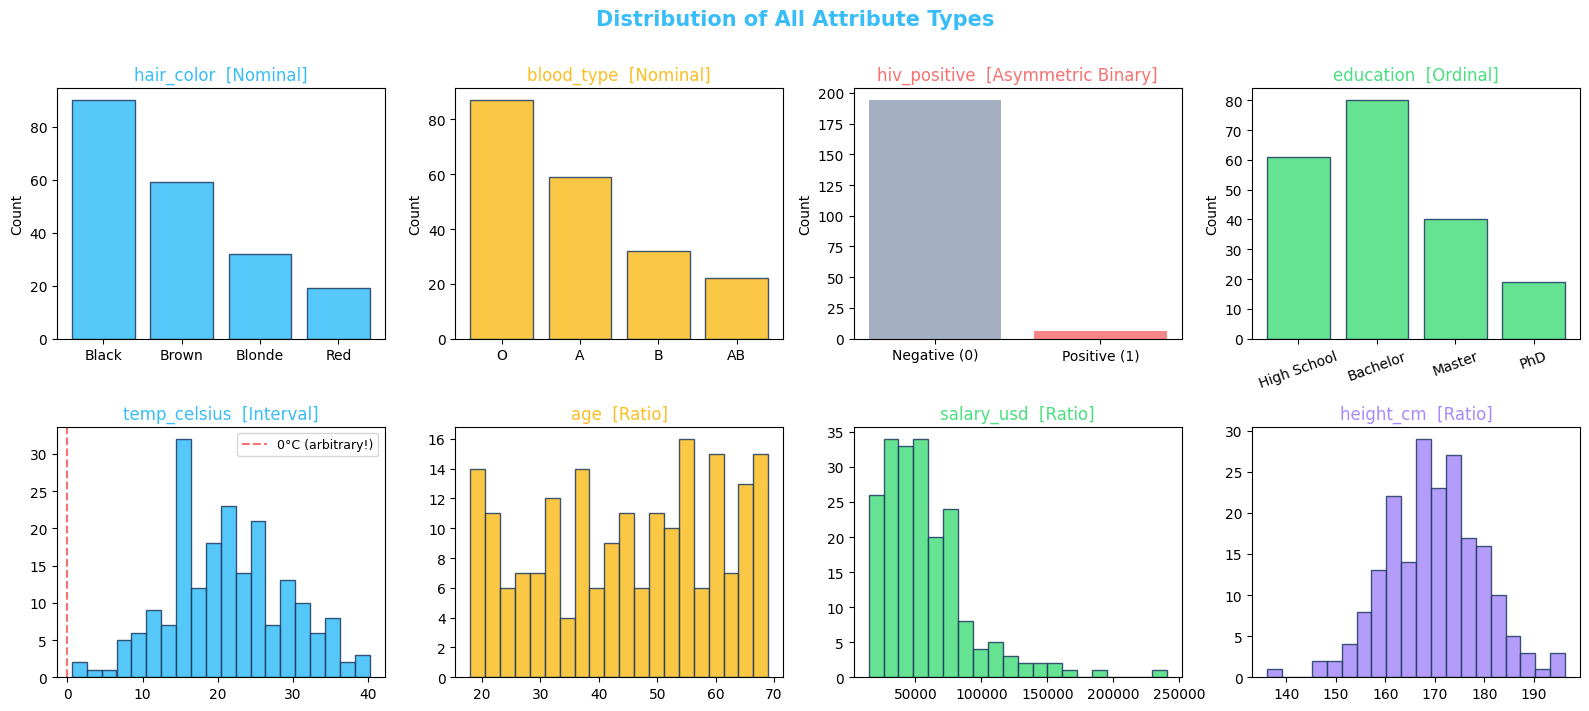

In [18]:
# ── Visualise attribute type distributions ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Distribution of All Attribute Types', fontsize=15, color=BLUE, fontweight='bold', y=1.01)

# Nominal
for ax, col, color in zip(axes[0, :2],
                           ['hair_color','blood_type'],
                           [BLUE, AMBER]):
    vc = data[col].value_counts()
    ax.bar(vc.index, vc.values, color=color, alpha=0.85, edgecolor='#1E3A5F')
    ax.set_title(f'{col}  [Nominal]', color=color)
    ax.set_ylabel('Count')

# Binary asymmetric
vc = data['hiv_positive'].value_counts()
axes[0,2].bar(['Negative (0)','Positive (1)'], vc.values, color=[MUTED, RED], alpha=0.85)
axes[0,2].set_title('hiv_positive  [Asymmetric Binary]', color=RED)
axes[0,2].set_ylabel('Count')

# Ordinal
vc = data['education'].value_counts().reindex(['High School','Bachelor','Master','PhD'])
axes[0,3].bar(vc.index, vc.values, color=GREEN, alpha=0.85, edgecolor='#1E3A5F')
axes[0,3].set_title('education  [Ordinal]', color=GREEN)
axes[0,3].set_ylabel('Count')
axes[0,3].tick_params(axis='x', rotation=20)

# Interval
axes[1,0].hist(data['temp_celsius'], bins=20, color=BLUE, alpha=0.85, edgecolor='#1E3A5F')
axes[1,0].set_title('temp_celsius  [Interval]', color=BLUE)
axes[1,0].axvline(0, color=RED, lw=1.5, linestyle='--', label='0°C (arbitrary!)')
axes[1,0].legend(fontsize=9)

# Ratio
for ax, col, color in zip(axes[1, 1:],
                            ['age','salary_usd','height_cm'],
                            [AMBER, GREEN, PURPLE]):
    ax.hist(data[col], bins=20, color=color, alpha=0.85, edgecolor='#1E3A5F')
    ax.set_title(f'{col}  [Ratio]', color=color)

plt.tight_layout()
plt.show()

In [19]:
# ── Demonstrate why you CANNOT average nominal codes ───────────────────
# Assign codes: Black=1, Brown=2, Blonde=3, Red=4
code_map = {'Black':1, 'Brown':2, 'Blonde':3, 'Red':4}
coded = data['hair_color'].map(code_map)
mean_code = coded.mean()
reverse_map = {v:k for k,v in code_map.items()}

print("=== Demonstration: Nominal Attribute Trap ===")
print(f"Coding: {code_map}")
print(f"Mean code: {mean_code:.2f}")
# Round to nearest integer and map back
nearest = round(mean_code)
print(f"Rounded to {nearest} → '{reverse_map[nearest]}'")
print()
print("⚠  But if we had chosen codes Black=10, Brown=20, Blonde=30, Red=40,")
code_map2 = {'Black':10, 'Brown':20, 'Blonde':30, 'Red':40}
coded2 = data['hair_color'].map(code_map2)
print(f"   Mean code would be {coded2.mean():.1f} → different answer, same data!")
print()
print("✅ Conclusion: only Mode is a valid summary for nominal attributes.")
print(f"   Most common hair color: {data['hair_color'].mode()[0]}")

=== Demonstration: Nominal Attribute Trap ===
Coding: {'Black': 1, 'Brown': 2, 'Blonde': 3, 'Red': 4}
Mean code: 1.90
Rounded to 2 → 'Brown'

⚠  But if we had chosen codes Black=10, Brown=20, Blonde=30, Red=40,
   Mean code would be 19.0 → different answer, same data!

✅ Conclusion: only Mode is a valid summary for nominal attributes.
   Most common hair color: Black
